# XGBoost — Strategy A: SMOTE

This notebook trains and evaluates an XGBoost classifier using Strategy A for class imbalance handling. In this strategy, SMOTE is applied to the preprocessed training set to balance the minority diabetes class.

The model is trained on the SMOTE-balanced training data and evaluated on the original untouched test set. The results are saved for later comparison with the scale-pos-weight XGBoost model and the other machine learning models.

In [13]:
import pandas as pd
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, classification_report

In [14]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

print(f"Resampled class distribution: {Counter(y_train_resampled)}")



Resampled class distribution: Counter({np.int64(0): 16873, np.int64(1): 16873})


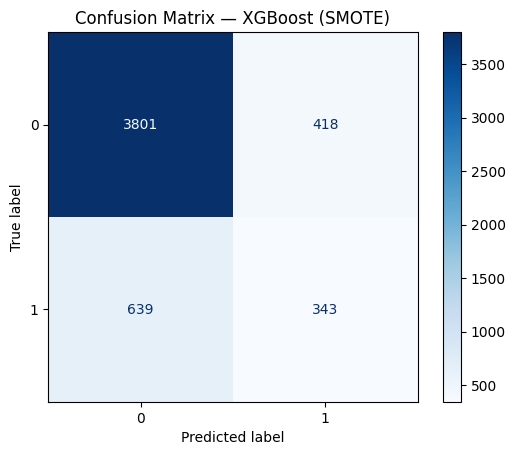

Confusion Matrix:
[[3801  418]
 [ 639  343]]
Accuracy: 0.7968
ROC AUC: 0.7755

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      4219
         1.0       0.45      0.35      0.39       982

    accuracy                           0.80      5201
   macro avg       0.65      0.63      0.64      5201
weighted avg       0.78      0.80      0.79      5201



In [16]:
model = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42)
model.fit(X_train_resampled, y_train_resampled)

predictions = model.predict(X_test_final)
pred_probabilities = model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (SMOTE)")
plt.show()

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))


